# Idea
this is a follow up on trend_forecast2.ipynb

## Data
I want to load the "interesting" subsets I have found:
- based on Flags of Events (Shock- Magnetic Obstacles)
- mased on orbital decay over 1 orbital period of GRACE-FO-1
and merge them into one dataset

## Forecasting Model

I want a forecasting model including
- ('orbital_decay')
- '|avg B|'
- 'F10.7 (LASP)'
- 'Bz GSE'
- 'Flow Speed (km/s'
- 'Temperature (K)'

but I want to test different models
- LinearRegression()
- Lasso()

to see the impact of regularisation

# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from numpy.polynomial import Polynomial
from statsmodels.tsa.seasonal import STL
from sklearn.metrics import root_mean_squared_error, r2_score
from pathlib import Path
from utils.data_loader import load_parquet, find_repo_root
from utils.plot_loader import create_subset
from utils.modeling import statistics, make_lags, make_multistep_target, aggregate_multistep_predictions

# Load Data

In [2]:
# Load only specific columns needed for analysis
columns_needed = ['time', 'orbital_decay', '|avg B|', 'F10.7 (LASP)', 'Bz GSE', 'Flow Speed (km/s', 'Temperature (K)', 'Kp (LASP)']

GFOC_data = load_parquet(columns=columns_needed)
print(GFOC_data.head())

✅ Successfully loaded data with shape: (3157920, 8)
                 time  orbital_decay   |avg B|  F10.7 (LASP)    Bz GSE  \
0 2023-01-01 00:00:00        16.6730  5.630000         153.0 -0.960000   
1 2023-01-01 00:00:20        16.6730  5.633333         153.0 -0.426667   
2 2023-01-01 00:00:40        16.6735  5.636667         153.0  0.106667   
3 2023-01-01 00:01:00        16.6740  5.640000         153.0  0.640000   
4 2023-01-01 00:01:20        16.6740  5.633333         153.0  0.190000   

   Flow Speed (km/s  Temperature (K)  Kp (LASP)  
0        595.600000          80634.0      2.333  
1        595.600000          80634.0      2.333  
2        595.600000          80634.0      2.333  
3        595.600000          80634.0      2.333  
4        593.066667          82111.0      2.333  


## Subsets

In [3]:
def load_intervals(csv_paths):
    """Load start/end intervals from one or more CSV files."""
    dfs = []
    for path in csv_paths:
        df = pd.read_csv(path, parse_dates=["start", "end"])
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

def merge_intervals(df):
    """Merge overlapping time intervals."""
    # Sort intervals by start time
    df = df.sort_values("start").reset_index(drop=True)

    merged = []
    current_start = df.loc[0, "start"]
    current_end = df.loc[0, "end"]

    for i in range(1, len(df)):
        row_start = df.loc[i, "start"]
        row_end = df.loc[i, "end"]

        if row_start <= current_end:  
            # Overlapping or touching intervals → extend the end if needed
            current_end = max(current_end, row_end)
        else:  
            # No overlap → push current and reset
            merged.append((current_start, current_end))
            current_start = row_start
            current_end = row_end

    # Append final interval
    merged.append((current_start, current_end))

    return pd.DataFrame(merged, columns=["start", "end"])


csv_files = [
    find_repo_root() / Path("Analysis/modeling/subsets_eflag.csv"),
    find_repo_root() / Path("Analysis/modeling/subsets_meanstd.csv")
]

intervals_df = load_intervals(csv_files)
# add timedelta
t01 = pd.Timedelta(hours=72)  # extension before 0->1
t10 = pd.Timedelta(hours=12)  # extension after 1->0
intervals_df['start'] = intervals_df['start'] - t01
intervals_df['end'] = intervals_df['end'] + t10
# merge
merged_df = merge_intervals(intervals_df)
print(f"# subsets: {len(merged_df)}")

# subsets: 37


### Copy data to new DataFrame and create Index

In [4]:
df = create_subset(GFOC_data, GFOC_data.iloc[0]['time'], GFOC_data.iloc[-1]['time'], resample_rate='5min')
# time delta in seconds
dt_seconds = (df.index[1] - df.index[0]).total_seconds()

### Compute secondary parameters

In [5]:
# daily means
df['median_decay_last_7D'] = df['orbital_decay'].rolling(window=int(7*24*60*(60/dt_seconds)), min_periods=1).median()
df['median_decay_last_14D'] = df['orbital_decay'].rolling(window=int(14*24*60*(60/dt_seconds)), min_periods=1).median()
df['median_decay_last_30D'] = df['orbital_decay'].rolling(window=int(30*24*60*(60/dt_seconds)), min_periods=1).median()

# polynomial coefficients for orbital period (minutes) as function of time (years since 2000)
p_list = [1.06605722e+02, -7.21846851e-09]
p = Polynomial(p_list)
# compute orbital period and phase
orbital_period = p(df.index.astype(np.int64) / 1e9) * 60 # seconds
# cumulative orbital cycles over time
cycles = np.cumsum(1 / orbital_period) * dt_seconds   # because your sampling is every 20s
# phase angle
df["orbital_period"] = orbital_period
df["phase"] = (2 * np.pi * cycles) % (2 * np.pi)
# add more harmonics to potentialy capture other periodicities; if not useful the lasso should zero them out
num_harmonics = 4
for n in range(1, num_harmonics + 1):
    df[f'sin_harmonic_{n}'] = np.sin(n * df["phase"])
    df[f'cos_harmonic_{n}'] = np.cos(n * df["phase"])

### Illustrate where the "interesting" subsets are

In [6]:
df['e_flag'] = 0

# mo flags
interval_starts = pd.to_datetime(merged_df['start']).dropna()

interval_ends = pd.to_datetime(merged_df['end']).dropna()

intervals = list(zip(interval_starts, interval_ends))
for start, end in intervals:
    df.loc[(df.index >= start) & (df.index <= end), 'e_flag'] = 1

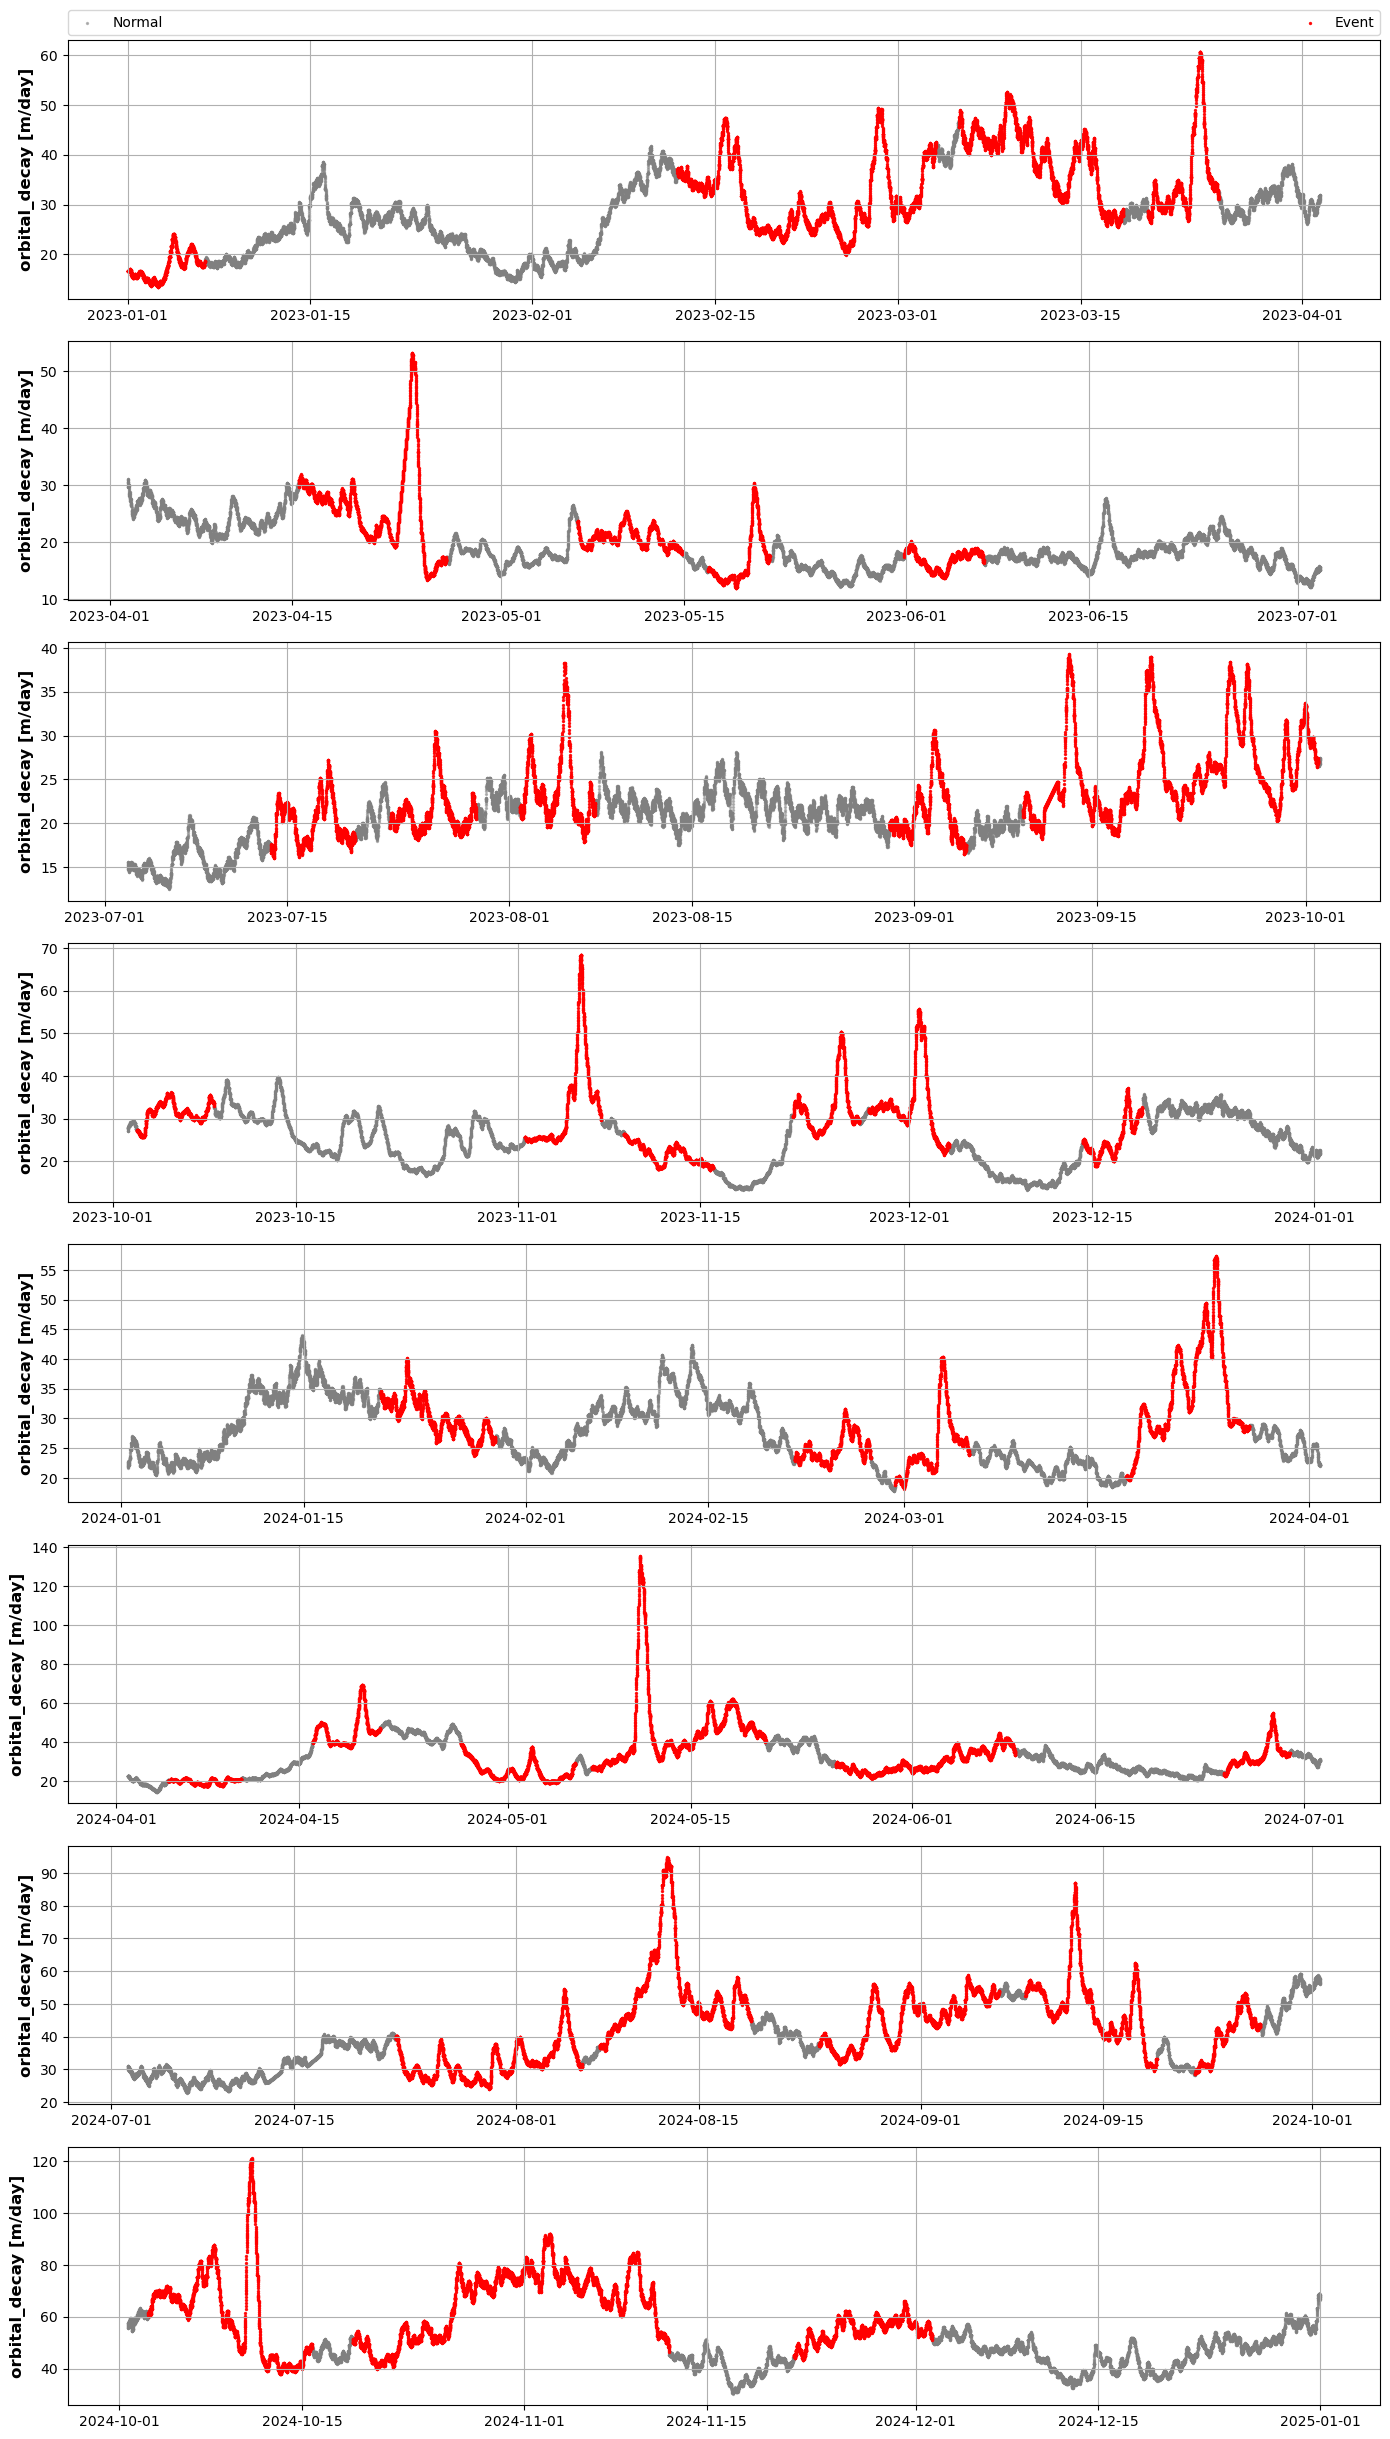

In [7]:
N = 8  # number of subplots

# Downsampled view
ysub = df.iloc[::1]

# split indices into N nearly equal chunks
splits = np.array_split(ysub.index, N)
plt.close('all')
fig, axes = plt.subplots(N, 1, figsize=(14, 3*N), sharey=False)

for ax, idx_chunk in zip(axes, splits):

    # slice the dataframe for this subplot
    chunk = ysub.loc[idx_chunk]

    flagged   = chunk[chunk['e_flag'] == 1]
    unflagged = chunk[chunk['e_flag'] == 0]

    ax.scatter(
        unflagged.index,
        unflagged['orbital_decay'],
        s=2,
        color='gray',
        alpha=0.5,
        label='Normal'
    )

    ax.scatter(
        flagged.index,
        flagged['orbital_decay'],
        s=2,
        color='red',
        alpha=0.9,
        label='Event'
    )

    ax.grid(True)
    ax.set_ylabel("orbital_decay [m/day]")

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0].legend(by_label.values(), by_label.keys(),
    bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left',
    ncols=4, mode="expand", borderaxespad=0.)
plt.tight_layout(rect=[0, 0, 1, 1.02])
plt.show()

### Load data into subsets

In [8]:
subsets = []

for start, end in intervals:
    subset = df.loc[start:end]
    
    # STL parameters
    mean_period_s = np.nanmedian(orbital_period)  # seconds per cycle
    period_samples = int(round(mean_period_s / dt_seconds))
    seasonal = 20 * period_samples + (20 * period_samples % 2 == 0) # Ensure odd
    low_pass_jump = seasonal_jump = int(0.15 * (period_samples + 1))
    trend_jump = int(0.15 * 1.5 * (period_samples + 1))
    # stl = STL(subset["orbital_decay"], period=period_samples, robust=True)
    stl = STL(
        subset["orbital_decay"],
        period=period_samples,
        seasonal=seasonal,
        seasonal_jump=seasonal_jump,
        trend_jump=trend_jump,
        low_pass_jump=low_pass_jump,
    )
    res = stl.fit()
    subset["osc_stl"] = res.seasonal
    subset["trend_stl"] = res.trend
    subset["resid_stl"] = res.resid
    # set variables
    subset["oscillation"] = subset["osc_stl"] + subset["resid_stl"]
    subset["trend"] = subset["trend_stl"]

    subsets.append(subset)

# create single dataframe of all subsets
subset_dfs = []
for subset in subsets:
    subset_dfs.append(subset)
df_all_subsets = pd.concat(subset_dfs)

# Multioutput Model

In [9]:
hour = int(60 / (dt_seconds / 60))  # number of samples in one hour
lag_config_trend = {
    # removed having target data as feature to avoid data leakage given the target signal is spread out
    # "orbital_decay": {"lags": list(range(1*hour, 24*hour, 3*hour))}, 
    "|avg B|": {'lags': list(range(1, 3*hour, max(hour//10, 1))) + list(range(3*hour, 50*hour, max(hour//2, 1)))},
    "Bz GSE": {'lags': list(range(1, 3*hour, max(hour//10, 1))) + list(range(3*hour, 50*hour, max(hour//2, 1)))},
    "Temperature (K)": {'lags': list(range(1, 3*hour, max(hour//10, 1))) + list(range(3*hour, 50*hour, max(hour//2, 1)))},
    "Flow Speed (km/s": {'lags': list(range(1, 3*hour, max(hour//10, 1))) + list(range(3*hour, 50*hour, max(hour//2, 1)))},
    "F10.7 (LASP)": {'lags': list(range(1, 24*hour, 6*hour)) + list(range(24*hour, 50*hour, 12*hour))},
    "median_decay_last_7D": {'lags': list(range(1, 50*hour, 12*hour))},
    "median_decay_last_14D": {'lags': list(range(1, 50*hour, 12*hour))},
    "median_decay_last_30D": {'lags': list(range(1, 50*hour, 12*hour))}
}

X_trend_list = []

y_trend_list = []
target = 'trend'
n = 12  # hours ahead
y_stepsize = int(15 * (60 / dt_seconds)) # every 15 minutes

for subset in subsets:
    X_trend = make_lags(subset, lag_config_trend)

    y_trend = make_multistep_target(subset[[target]].copy(), steps=int(n * 60 * (60 / dt_seconds)), stepsize=y_stepsize)

    # Shifting has created indexes that don't match. Only keep times for
    na_mask = X_trend.isna().any(axis=1) | y_trend.isna().any(axis=1)
    X_trend = X_trend[~na_mask]
    y_trend = y_trend[~na_mask]

    # Rename columns to avoid MultiIndex issues
    X_trend.columns = ['_'.join(map(str, col)) if isinstance(col, tuple) else str(col) for col in X_trend.columns]

    X_trend_list.append(X_trend)
    y_trend_list.append(y_trend)

## Split into training and test sets and Merge

In [10]:
no_test_subsets = 8

X_train = pd.concat(X_trend_list[:-no_test_subsets])
y_train = pd.concat(y_trend_list[:-no_test_subsets])
X_test = pd.concat(X_trend_list[-no_test_subsets:])
y_test = pd.concat(y_trend_list[-no_test_subsets:])

## Training

check if MultiTask is sensible: If targets are 
- strongly correlated --> use MultiTaskLassoCV
- weakly correlated --> use seperate LassoCVs

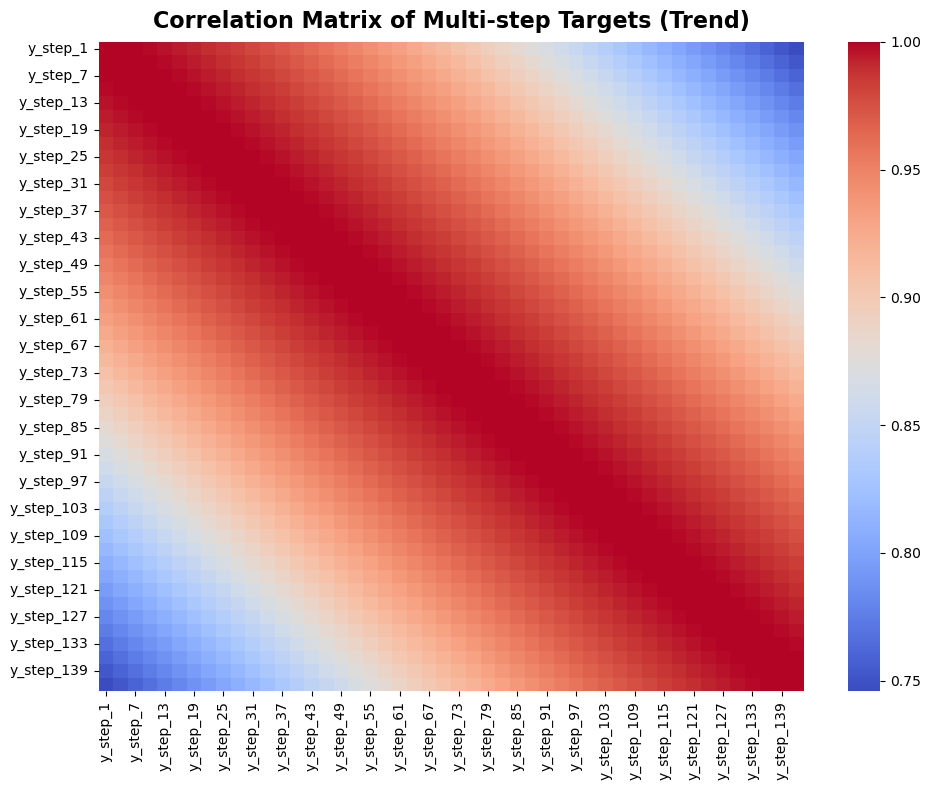

In [13]:
y_train.corr()

# plot matrix of correlations
plt.figure(figsize=(10, 8))
sns.heatmap(y_train.corr(), annot=False, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Multi-step Targets (Trend)")
plt.show()

### Interpretation

The minimum pairewise correlation of 0.75 indicates that all outputs are strongly coupled. Thus they likely share the same physical drivers.

--> use MultiTastLassoCV

In [ ]:
from sklearn.linear_model import LinearRegression, Lasso, MultiTaskLassoCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# scale and convert back to DataFrames
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    index=X_train.index,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    index=X_test.index,
    columns=X_test.columns
)

# alphas = np.logspace(-2, 1, 40)
alphas = np.logspace(-1.3, 0.7, 20)
# model_trend = LinearRegression()
# model_trend = Lasso(alpha=0.3)
model_trend = MultiTaskLassoCV(
    alphas=alphas, 
    cv=3,
    max_iter=5000,
    n_jobs=-1
)

if False:
    # Train only on active times
    active_times = df[df['Kp (LASP)'] >= 4].index.intersection(X_train_scaled.index)
    model_trend.fit(
        X_train_scaled.loc[active_times],
        y_train.loc[active_times]
    )
else:
    # Train on all times
    model_trend.fit(X_train_scaled, y_train)

y_train_pred = pd.DataFrame(model_trend.predict(X_train_scaled), index=X_train.index, columns=y_train.columns)
y_test_pred = pd.DataFrame(model_trend.predict(X_test_scaled), index=X_test.index, columns=y_test.columns)

# Results

## Check Coefficients

In [12]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model_trend.coef_[1, :]
})
coef_df = coef_df.sort_values(by='coefficient', key=abs, ascending=False)
coef_df['lag_hours'] = coef_df['feature'].apply(lambda x: f"{int(x.split('_')[-1]) * (dt_seconds / 3600):.2f}" if 'lag' in x else np.nan)
coef_df.head(10)

,feature,coefficient,lag_hours
523,median_decay_last_7D_lag_1,4.227862,0.08
533,median_decay_last_30D_lag_1,2.456579,0.08
516,F10.7 (LASP)_lag_1,1.829740,0.08
532,median_decay_last_14D_lag_577,-1.386657,48.08
0,|avg B|_lag_1,0.730276,0.08
387,Flow Speed (km/s_lag_1,0.496068,0.08
517,F10.7 (LASP)_lag_73,0.489376,6.08
129,Bz GSE_lag_1,-0.370175,0.08
36,|avg B|_lag_42,0.338055,3.50
38,|avg B|_lag_54,0.289478,4.50


Train RMSE: 5.18
Test RMSE: 7.68
Train R2: 0.781
Test R2: 0.769


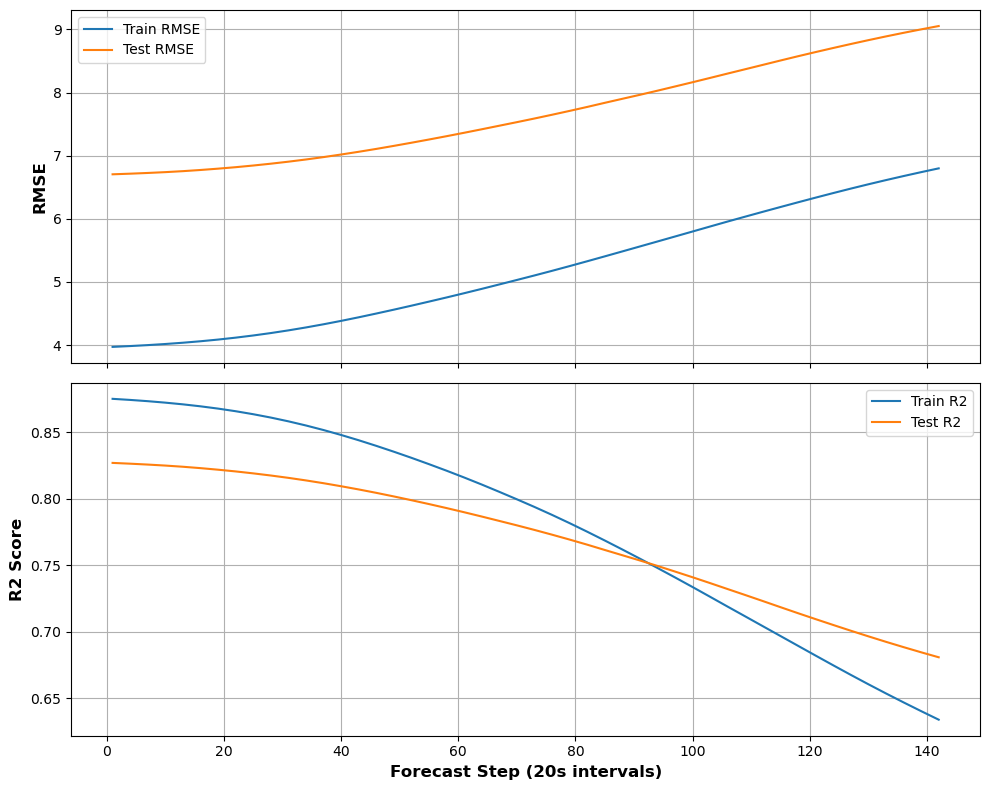

In [13]:
statistics(y_train, y_train_pred, y_test, y_test_pred)

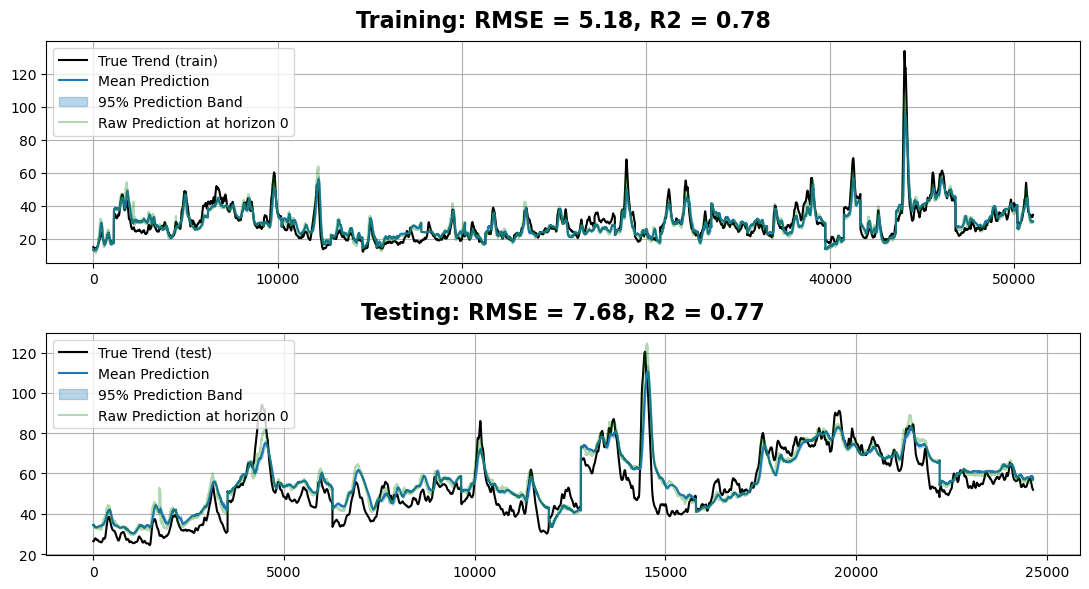

In [14]:
od_train = aggregate_multistep_predictions(y_train, dt_seconds=dt_seconds, error_kind='sem')
od_test = aggregate_multistep_predictions(y_test, dt_seconds=dt_seconds, error_kind='sem')
od_train_pred = aggregate_multistep_predictions(y_train_pred, dt_seconds=dt_seconds, error_kind='sem')
od_test_pred = aggregate_multistep_predictions(y_test_pred, dt_seconds=dt_seconds, error_kind='sem')

train_range = range(len(od_train))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6))
ax1.plot(train_range, od_train['mean'], color='black')
ax1.plot(train_range, od_train_pred['mean'], color='C0')
ax1.fill_between(train_range, od_train_pred['mean'] - 1.96 *od_train_pred['sem'], od_train_pred['mean'] + 1.96 *od_train_pred['sem'], color='C0', alpha=0.3)
ax1.plot(train_range, od_train_pred['horizon0'], color='green',  alpha=0.3)
_ = ax1.legend(['True Trend (train)', 'Mean Prediction', '95% Prediction Band', 'Raw Prediction at horizon 0'])
ax1.grid(True)
ax1.set_title(f"Training: RMSE = {root_mean_squared_error(y_train, y_train_pred):.2f}, R2 = {r2_score(y_train, y_train_pred):.2f}")

test_range = range(len(od_test))
# plot complete forecast horizon
ax2.plot(test_range, od_test['mean'], color='black')
ax2.plot(test_range, od_test_pred['mean'], color='C0')
ax2.fill_between(test_range, od_test_pred['mean'] - 1.96 *od_test_pred['sem'], od_test_pred['mean'] + 1.96 *od_test_pred['sem'], color='C0', alpha=0.3)
ax2.plot(test_range, od_test_pred['horizon0'], color='green',  alpha=0.3)
_ = ax2.legend(['True Trend (test)', 'Mean Prediction', '95% Prediction Band', 'Raw Prediction at horizon 0'])
ax2.grid(True)
ax2.set_title(f"Testing: RMSE = {root_mean_squared_error(y_test, y_test_pred):.2f}, R2 = {r2_score(y_test, y_test_pred):.2f}")
plt.tight_layout()
plt.show()

### Plot subsets

In [15]:
def split_by_time_gap(df, dt_seconds):
    """
    Split a DataFrame into subsets whenever time difference > dt_seconds.
    df.index must be a DatetimeIndex unless time_col is given.
    """
    t = pd.to_datetime(df.index)

    gaps = t.diff().total_seconds() > dt_seconds
    groups = pd.Series(gaps.cumsum(), index=df.index)

    return [df.loc[groups == g] for g in groups.unique()]

def plot_subsets(true_subsets, pred_subsets, title_prefix):
    rows = len(true_subsets)
    i = 0
    fig, axes = plt.subplots(rows, 1, figsize=(11, 3*rows))

    if rows == 1:
        axes = [axes]

    for ax, df_true, df_pred in zip(axes, true_subsets, pred_subsets):
        ax.plot(df_true.index, df_true['mean'], color='black')
        ax.plot(df_pred.index, df_pred['mean'], color='C0')
        ax.fill_between(df_pred.index,
                        df_pred['mean'] - 1.96 * df_pred['sem'],
                        df_pred['mean'] + 1.96 * df_pred['sem'],
                        color='C0', alpha=0.3)
        ax.plot(df_pred.index, df_pred['horizon0'], color='green', alpha=0.3)

        ax.legend(['True Trend', 'Mean Prediction', '95% Prediction Band', 'Raw Prediction (horizon 0)'])
        ax.grid(True)

        subset_start = df_true.index.min().strftime('%Y-%m-%d %H:%M:%S')
        ax.set_title(f"{title_prefix} subset {i}, starting {subset_start}")
        i += 1

    plt.tight_layout()
    plt.show()


In [16]:
train_subsets = split_by_time_gap(od_train, dt_seconds)
train_pred_subsets = split_by_time_gap(od_train_pred, dt_seconds)

test_subsets = split_by_time_gap(od_test, dt_seconds)
test_pred_subsets = split_by_time_gap(od_test_pred, dt_seconds)

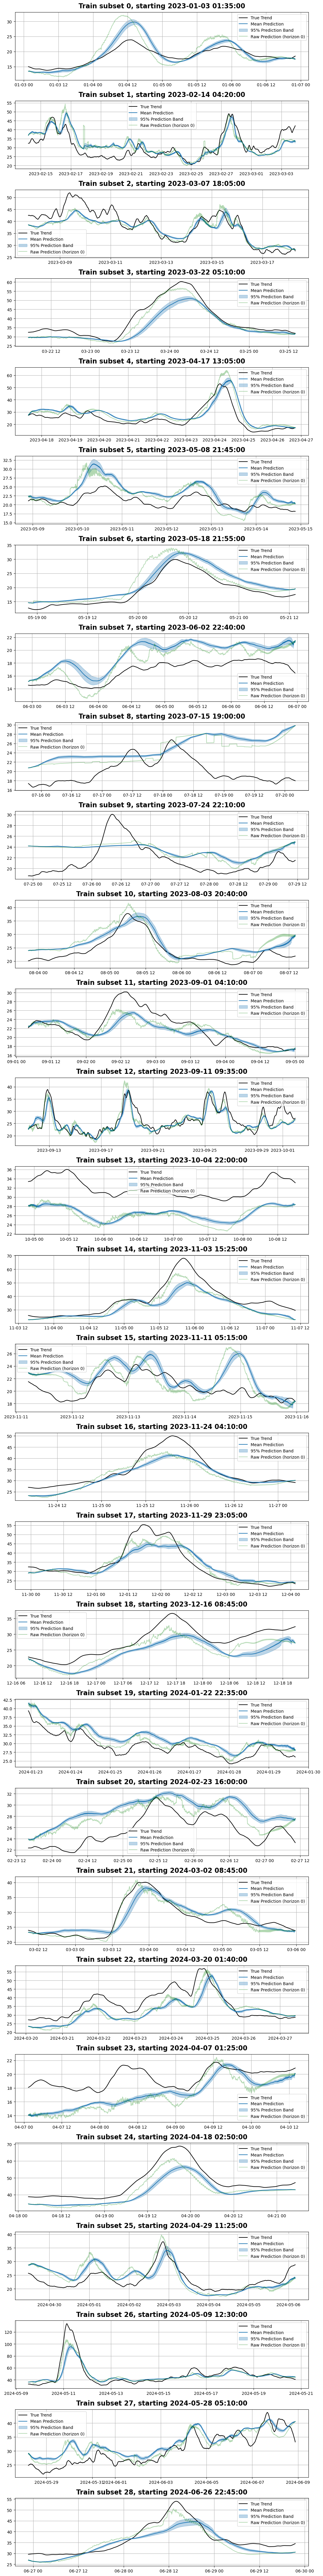

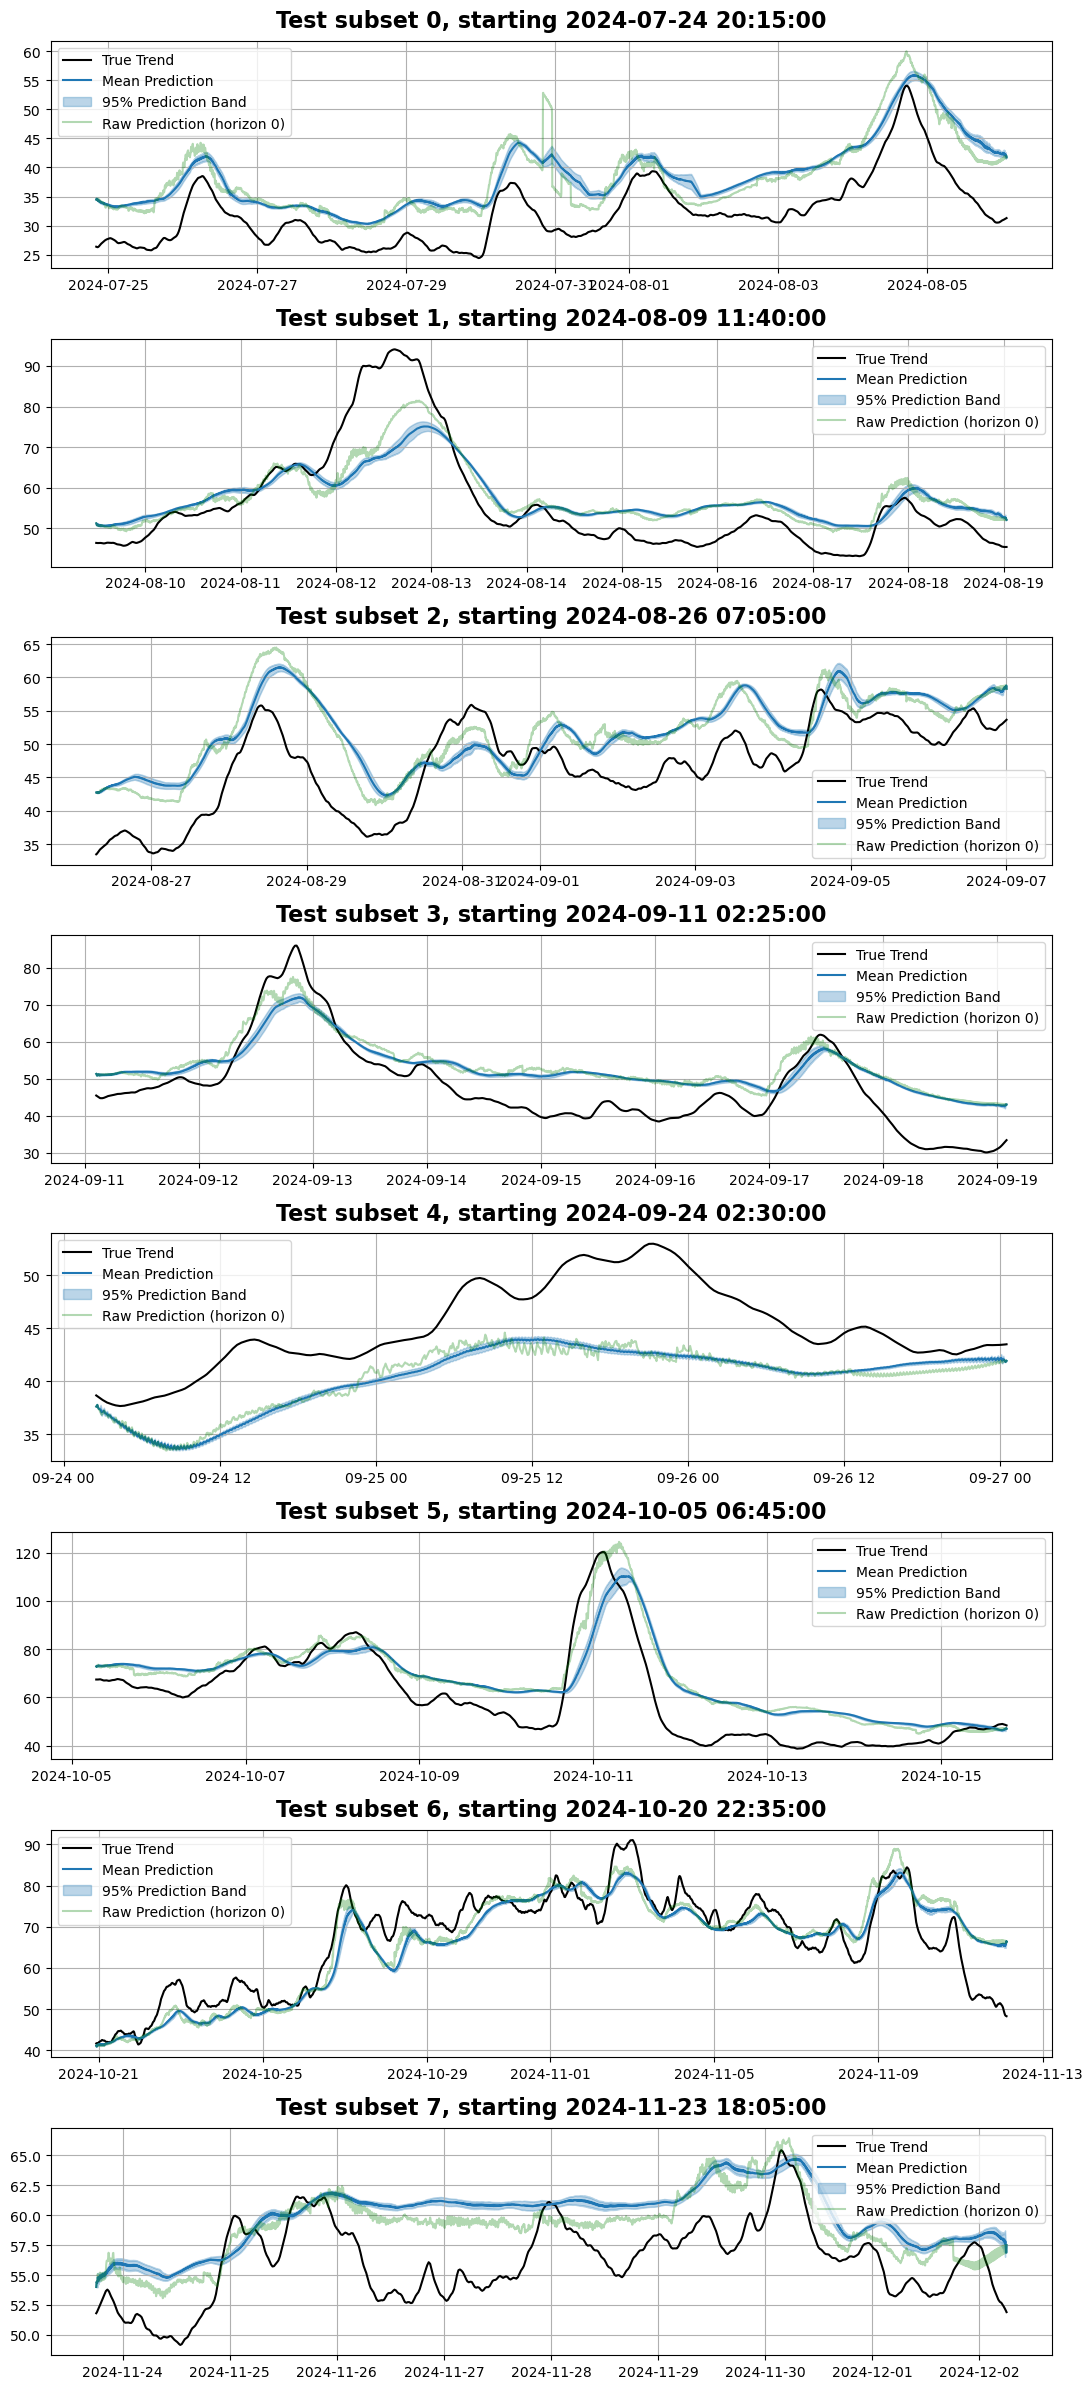

In [17]:
plot_subsets(train_subsets, train_pred_subsets, "Train")
plot_subsets(test_subsets, test_pred_subsets, "Test")

## Plot single forecasts

In [34]:
def plot_forecast_for_event(event_id, time):
    idx = y_test.index.get_loc(time)
    time_idx = y_test.index[idx]

    # Extract sample
    sample_test = X_test.iloc[idx]
    sample_test_F = sample_test.filter(like='F10.7')
    sample_test_B = sample_test.filter(like='|avg B|')
    sample_test_y = y_test.iloc[idx]

    # Compute lag times
    lag_times_F = [-int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_F.index]
    lag_times_B = [-int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_B.index]
    lag_times_y = [int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_y.index]

    sample_test_F.index = lag_times_F
    sample_test_B.index = lag_times_B

    # Define time window for decay plotting
    time_window = (time_idx - pd.Timedelta(hours=24), time_idx + pd.Timedelta(hours=24))
    true_decay = df_all_subsets.loc[time_window[0]:time_window[1], target]
    pred_trend = y_test_pred.iloc[idx]
    bz_window = df_all_subsets.loc[time_window[0]:time_window[1], '|avg B|']

    fig, ax = plt.subplots(figsize=(10, 6), nrows=2)
    ax = ax.flatten()

    # Plot lagged features
    ax[0].scatter(sample_test_F.index, sample_test_F.values, color='blue')
    ax2 = ax[0].twinx()
    ax2.scatter(sample_test_B.index, sample_test_B.values, color='orange', alpha=0.7)

    ax[0].set_title(f'Input lags for F10.7 and |avg B| for event id {event_id}\n{y_test.iloc[idx].name}')
    ax[0].set_xlabel('Lagged Features')
    ax[0].set_ylabel('F10.7 Value', color='blue')
    ax2.set_ylabel('|avg B| Value', color='orange')
    ax[0].grid(True)

    xticks = ax[0].get_xticks()
    ax[0].set_xticklabels([f'{int(t/60)}h' for t in xticks])

    # Plot decay trends
    ax[1].plot(true_decay.index, true_decay.values, label='True Decay', color='black')
    pred_times = [time_idx + pd.Timedelta(minutes=10 * (i + 1)) for i in range(len(pred_trend))]
    ax[1].plot(pred_times, pred_trend.values, marker='.', linestyle='None', color='red', label='Predicted Decay')

    ax[1].set_title('Predicted Decay vs. True Decay')
    ax[1].set_xlabel('Time')
    ax[1].set_ylabel('Decay Rate (m/day)')
    ax[1].legend()
    ax[1].grid(True)

    # Overlay |avg B| on second plot
    ax2 = ax[1].twinx()
    ax2.scatter(bz_window.index, bz_window.values, color='blue', alpha=0.8, s=1)
    ax2.set_ylabel('|avg B|', color='blue')

    # Mark forecast horizon start time
    ax[1].axvline(time_idx, color='gray', linestyle='--', label='Forecast Horizon Start Time')

    plt.tight_layout()
    plt.show()

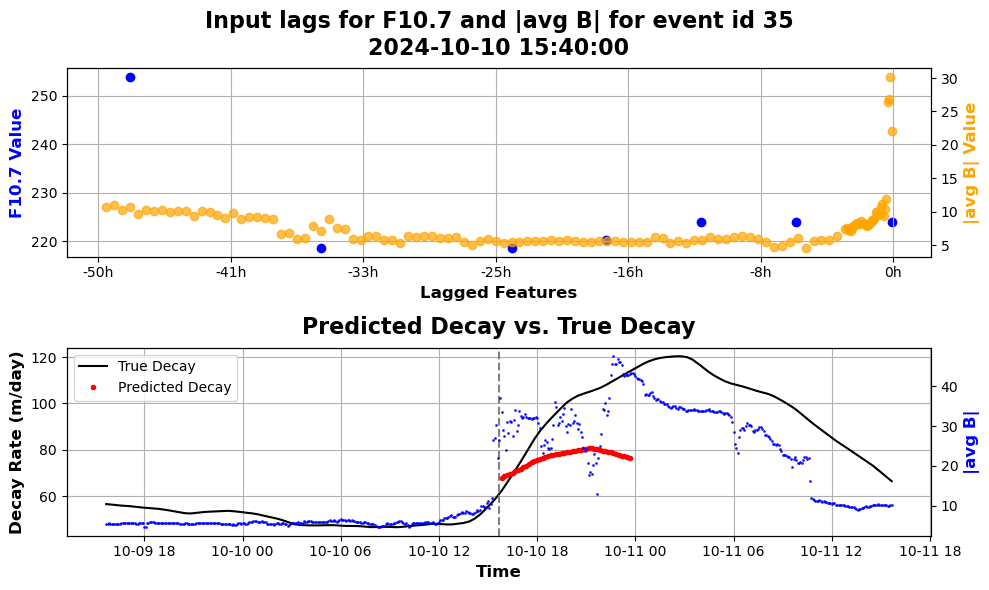

In [35]:
event_id = 35
event_time = '2024-10-10 15:40:00'
plot_forecast_for_event(event_id, event_time)